# 2차원 경로 계획의 형상 공간(Configuration space) 연결성 분석

### 기하학적 feasibility boundary와 직접 구현한 grid A*의 비교

A mini research project on geometric feasibility and grid-based motion planning

**장애물 좌표 → 접촉 임계값 → minimax barrier → 연속 공간 임계반지름 → A* 수치 검증**

을 하나의 재현 가능한 실험으로 연결한다.

이 노트북은 이전 이론적으로 구성한 장애물 배치와 수정된 V자형 이론식을 사용한다.
A*와 minimax는 `heapq`로 직접 구현하며 NetworkX나 경로탐색 라이브러리를 쓰지 않는다. NumPy는 배열 계산, Matplotlib은 그림 생성에만 사용한다.


**범위:** 정적 원형 장애물과 원형 holonomic robot의 2D 기하학적 planning이다.
동적 객체 prediction, 차량 조향 제약, 가속도·승차감, 실제 도로 성능은 검증하지 않는다. 지원서에는 실제로 수행한 이 범위를 명확히 적는다.


## 프로젝트 구성과 실행 순서

| 단계 | 내용 | 주요 산출물 |
|---:|---|---|
| 1 | 문제와 형상 공간(configuration space) 모델 정의 | 작업공간, 장애물, 로봇 반지름, 충돌 조건 |
| 2 | 장애물·벽 사이의 접촉 임계값 계산과 가중 그래프 구성 | 모든 간선의 접촉 임계값 $\tau$ |
| 3 | 최소 최대(minimax) 장벽 계산과 이론식 검증 | $r_c(\delta)$, 차단 장벽, 구간별 이론식 |
| 4 | 격자 구성, 충돌 판정 및 A* 구현 | 격자 그래프, 경로 존재 여부, 기본 검증 결과 |
| 5 | $(\delta,r)$ 매개변수 공간 실험 | 통과 가능 영역과 이론 경계 비교 |
| 6 | 이론적 임계값과 격자 기반 관측값 비교 | 이분 탐색 구간과 관측 임계값 |
| 7 | 격자 해상도에 따른 오차와 계산량 비교 | 평균·최대 오차, 실행 시간, 탐색량 |
| 8 | 좁은 통로와 격자 정렬 사례 분석 | 격자점 개수 비교와 `06_grid_alignment.png` |
| 9 | 그림·표·실험 결과 저장 | `results/main/`의 PNG, CSV, JSON 파일 |
| 10 | 주요 결과와 적용 범위 정리 | 핵심 관찰, 한계 및 후속 확장 방향 |

노트북은 위 순서대로 실행한다. 이론 계산과 격자 기반 A*는 장애물 좌표만 공유하며, A*는 이론적 임계값을 입력으로 사용하지 않는다. 따라서 이론값과 수치 결과를 독립적으로 비교할 수 있다.

In [1]:
from pathlib import Path
from dataclasses import dataclass
from heapq import heappush, heappop
from time import perf_counter
import csv, json, platform, sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.colors import ListedColormap

OUT = Path('results/main')
OUT.mkdir(parents=True, exist_ok=True)
L, H = 12.0, 10.0
START, GOAL = (1.0, 5.0), (11.0, 5.0)
EPS = 1e-10  # 접촉을 충돌로 처리하는 작은 수치 허용오차
FULL_SWEEP = False  # True: 이전 대화의 0.01 간격 sweep (4,641회 A*)
SWEEP_H = 0.10
DELTA_SWEEP = np.linspace(-0.4, 0.5, 91 if FULL_SWEEP else 19)
RADII_SWEEP = np.linspace(0.4, 0.9, 51 if FULL_SWEEP else 11)
RESOLUTIONS = [0.10, 0.05, 0.025]
# 격자와 정확히 맞는 배치 및 맞지 않는 배치를 함께 검사한다.
DELTA_COMPARE = np.array([-0.4, -0.2, 0.0, 0.013, 0.05, 0.137, 0.3, 0.5])
BISECTION_TOL = 0.0005
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.2})
print('Python:', sys.version.split()[0], '| NumPy:', np.__version__,
      '| Matplotlib:', matplotlib.__version__)
print('Sweep calls:', len(DELTA_SWEEP) * len(RADII_SWEEP))


Python: 3.13.15 | NumPy: 2.1.3 | Matplotlib: 3.10.0
Sweep calls: 209


## 1. 문제 정의와 형상 공간 모델

$W=[0,12]\times[0,10]$,

robot radius $r$,

모든 obstacle radius $R_i=0.5$.

장애물
| 열 | 중심좌표 (위→아래) |
|---|---|
| A | $A_1 =(4,7.9),A_2 =(4,5.3),A_3= (4,2.7),A_4 =(4,1.0)$ |
| C | $C_1=(8,8.5),C_2=(8,6.2),C_3 =(8,3.8+\delta), C_4 = (8,1.5)$ |

$\delta\in[-0.4,0.5]$이며 $C_3$만 수직으로 움직인다. 접촉은 벽·장애물 모두 충돌로 통일한다.

따라서 로봇 중심은 열린 직사각형 $(r,12-r)\times(r,10-r)$ 안에 있어야 하고, $\|q-c_i\|>R_i+r$여야 한다.

이전 설명의 닫힌 $W_r$ 표기와 달리 **이 구현은 경계 접촉도 허용하지 않는다.**

이론의 top-bottom barrier는 일반적인 임의의 두 점 연결성 판정과 동일하지 않다.

여기서는 $r\in[0.4,0.9]$이고 팽창 장애물은 $x\in[2.6,5.4]$ 또는 $[6.6,9.4]$ 안에 있으므로, $s=(1,5)$와 $g=(11,5)$는 각각 장애물이 없는 좌·우 영역에 위치한다. 두 수직 열 사이에도 공간이 남는다.

따라서 이 배치에서는 좌→우 crossing과 선택한 start-goal 연결성의 임계값이 일치한다. 좌표를 임의로 바꿨을 때 이 성질까지 자동 보장되지는 않는다.


In [2]:
@dataclass(frozen=True)
class Obstacle:
    name: str
    x: float
    y: float
    radius: float = 0.5

def make_obstacles(delta):
    if not -0.4 - EPS <= delta <= 0.5 + EPS:
        raise ValueError('이 예제의 검증 범위는 delta in [-0.4, 0.5]입니다.')
    return [Obstacle(f'A{i+1}', 4.0, y) for i, y in enumerate([7.9, 5.3, 2.7, 1.0])] + [
        Obstacle(f'C{i+1}', 8.0, y) for i, y in enumerate([8.5, 6.2, 3.8+delta, 1.5])]

def point_clearance(q, obstacles):
    """이 위치에서 허용되는 robot radius의 supremum. 접촉 시 충돌."""
    x, y = q
    return min(x, L-x, y, H-y,
               *(np.hypot(x-o.x, y-o.y)-o.radius for o in obstacles))

print([(o.name, (o.x, o.y)) for o in make_obstacles(0)])
assert min(point_clearance(START, make_obstacles(0)),
           point_clearance(GOAL, make_obstacles(0))) > 0.9


[('A1', (4.0, 7.9)), ('A2', (4.0, 5.3)), ('A3', (4.0, 2.7)), ('A4', (4.0, 1.0)), ('C1', (8.0, 8.5)), ('C2', (8.0, 6.2)), ('C3', (8.0, 3.8)), ('C4', (8.0, 1.5))]


## 2. 접촉 임계값과 가중 그래프

두 팽창 원이 처음 닿을 때 $R_i+r+R_j+r=\|c_i-c_j\|$이므로

$$\tau_{ij}=\frac{\|c_i-c_j\|-R_i-R_j}{2}.$$

벽도 로봇 중심의 금지영역을 $r$만큼 만들기 때문에

$$\tau_{iT}=\frac{H-y_i-R_i}{2},\qquad \tau_{iB}=\frac{y_i-R_i}{2}.$$

이미 겹친 원은 $r=0$부터 active이므로 edge weight에는 $\max(0,\tau)$를 저장한다. 모든 장애물 쌍과 Top/Bottom(T-B) 연결을 생성한다. 인접 원만 미리 선택하지 않으므로 예상하지 못한 혼합 chain도 계산에 포함된다. T-B 직접 edge $H/2$는 위·아래 벽의 금지영역이 만나 공간 높이가 소진되는 경우다. 본 실험에서는 훨씬 이전에 obstacle barrier가 생긴다.

$G$는 고정 weighted graph, $G_r=\{e:\tau_e\le r\}$는 반지름에 따라 활성화되는 graph다. **이 그래프의 경로는 로봇 경로가 아니라 차단 장벽이다.**


In [3]:
def tau_ij(a, b):
    return (np.hypot(a.x-b.x, a.y-b.y)-a.radius-b.radius)/2

def build_graph(obstacles):
    graph = {name: {} for name in ['T', 'B'] + [o.name for o in obstacles]}
    def add(u, v, weight):
        graph[u][v] = graph[v][u] = max(0.0, float(weight))
    for i, a in enumerate(obstacles):
        add('T', a.name, (H-a.y-a.radius)/2)
        add('B', a.name, (a.y-a.radius)/2)
        for b in obstacles[i+1:]:
            add(a.name, b.name, tau_ij(a, b))
    add('T', 'B', H/2)
    return graph

def active_connected(graph, r, start='T', goal='B'):
    seen, stack = {start}, [start]
    while stack:
        u = stack.pop()
        if u == goal:
            return True
        for v, w in graph[u].items():
            if w <= r + EPS and v not in seen:
                seen.add(v)
                stack.append(v)
    return False

graph0 = build_graph(make_obstacles(0))
for u, v in [('T','A1'), ('A1','A2'), ('C2','C3'), ('C3','C4'), ('C4','B')]:
    print(f'{u:>2} -- {v:<2}: tau = {graph0[u][v]:.3f}')


 T -- A1: tau = 0.800
A1 -- A2: tau = 0.800
C2 -- C3: tau = 0.700
C3 -- C4: tau = 0.650
C4 -- B : tau = 0.500


## 3. 최소 최대 장벽과 이론적 임계반지름

### 3.1 최소 최대 장벽 계산

$$r_c=\min_{P:T\leadsto B}\max_{e\in P}\tau_e.$$

하나의 chain이 완성되려면 그 chain의 **모든** edge가 active이어야 하므로 최대 weight가 필요하다. 여러 chain 중 하나만 완성되어도 막히므로 그 최대값들의 최소를 취한다.

Dijkstra의 누적합을 `max`로 바꾼다. `best[v]`는 T에서 v까지 가능한 최소 bottleneck이며 relaxation은 `candidate = max(best[u], weight(u,v))`이다. 작은 bottleneck부터 확정하므로 nonnegative weight에서 올바르게 작동한다. 부모 포인터를 저장해 실제 차단 chain도 복원한다. 시간복잡도는 heap 구현 기준 $O((V+E)\log V)$이다.


In [4]:
def minimax(graph, start='T', goal='B'):
    best = {v: float('inf') for v in graph}
    parent = {}
    best[start] = 0.0
    queue = [(0.0, start)]
    while queue:
        cost, u = heappop(queue)
        if cost > best[u]:
            continue
        if u == goal:
            path = [u]
            while path[-1] != start:
                path.append(parent[path[-1]])
            return cost, path[::-1]
        for v, weight in graph[u].items():
            candidate = max(cost, weight)
            if candidate < best[v]:
                best[v], parent[v] = candidate, u
                heappush(queue, (candidate, v))
    return float('inf'), []

def rc_graph(delta):
    return minimax(build_graph(make_obstacles(delta)))[0]

def rc_formula(delta):
    d = np.asarray(delta)
    return np.minimum(0.8, np.maximum(0.7-d/2, 0.65+d/2))

critical, barrier = minimax(graph0)
print('r_c(0) =', round(critical, 6), '| barrier:', ' -> '.join(barrier))


r_c(0) = 0.7 | barrier: T -> C1 -> C2 -> C3 -> C4 -> B


### 3.2  $r_c(\delta)$와 병목 구조(bottleneck)의 전환

왼쪽 chain의 threshold는 $r_A=\max(0.8,0.8,0.8,0.35,0.25)=0.8$.
오른쪽은 $r_C=\max(0.5,0.65,0.7- \frac{\delta}{2},0.65+\frac{\delta}{2}, 0.5)$.

두 열 사이 거리는 최소 4이므로 cross-column edge는 $\tau\ge(4-1)/2=1.5$이다. 각 열에서 비인접 원 사이의 edge도 0.8보다 크다. 따라서 $r\le0.8$에서 혼합 chain이나 shortcut이 먼저 장벽을 만들 수 없고 다음 식이 성립한다.

$$r_c(\delta)=\begin{cases}
0.8& -0.4\le\delta\le-0.2\\
0.7-\delta/2&-0.2\le\delta\le0.05\\
0.65+\delta/2&0.05\le\delta\le0.3\\
0.8&0.3\le\delta\le0.5.
\end{cases}$$

중앙 최솟값은 $r_c(0.05)=0.675$이며 따라서 $r_c(\delta)$는 $\delta=0.05$에서 최솟값을 갖는 V자형 구조를 보인다.

$\delta=0.05$에서 C2-C3와 C3-C4가 동시 bottleneck, $-0.2,0.3$에서는 두 열의 chain threshold가 같다. 동률일 때 minimax가 반환하는 chain은 최적 후보 중 하나다. $r<r_c$는 feasible, 접촉을 포함한 $r\ge r_c$는 infeasible이다.

아래에서는 손계산 식과 전체 graph 계산을 181개 배치에서 비교하고, 별도 DFS로 $r_c$ 직전/직후의 active graph 연결을 검증한다.


PASS: closed form, full minimax graph, active-graph DFS agree (181 layouts).


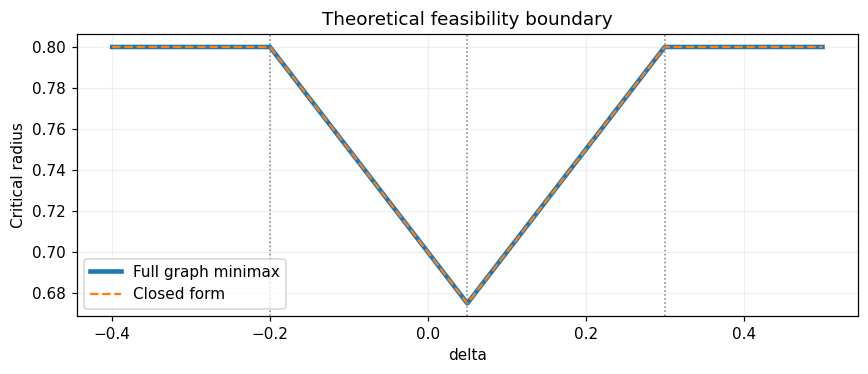

In [5]:
theory_deltas = np.linspace(-0.4, 0.5, 181)
theory_values = np.array([rc_graph(d) for d in theory_deltas])
np.testing.assert_allclose(theory_values, rc_formula(theory_deltas), atol=1e-12)
for d in theory_deltas:
    graph = build_graph(make_obstacles(d))
    rc, chain = minimax(graph)
    assert not active_connected(graph, rc-1e-7)
    assert active_connected(graph, rc)
    assert abs(max(graph[u][v] for u,v in zip(chain,chain[1:]))-rc) < 1e-12
print('PASS: closed form, full minimax graph, active-graph DFS agree (181 layouts).')
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(theory_deltas, theory_values, label='Full graph minimax', lw=3)
ax.plot(theory_deltas, rc_formula(theory_deltas), '--', label='Closed form')
for d in [-0.2, 0.05, 0.3]: ax.axvline(d, color='gray', ls=':', lw=1)
ax.set(xlabel='delta', ylabel='Critical radius', title='Theoretical feasibility boundary')
ax.legend(); fig.tight_layout(); plt.show()


## 4. 격자 기반 A* 구현

### 4.1 격자 이산화(Grid discretization)

격자 간격을 $h$로 놓고 $(x_i,y_j)=(ih,jh)$를 node로 사용한다. $h=0.05$이면 $241\times201=48,441$개 node다. 코드에서는 배열 index를 `(iy, ix)`로, 기하 좌표를 `(x, y)`로 명확히 구별한다. $L/h,H/h$가 정수가 아닌 값은 거절해 실제 간격과 입력 간격이 달라지는 문제를 방지한다.

8-neighbor edge는 수평·수직 길이 $h$, 대각선 길이 $\sqrt2 h$이다. occupancy는 셀 전체가 아닌 **grid node의 유효성**을 뜻하며 이동 edge의 유효성은 별도로 검사한다.


In [6]:
def grid_axes(h):
    if h <= 0:
        raise ValueError('h must be positive')
    nx, ny = int(round(L/h)), int(round(H/h))
    if not (np.isclose(nx*h, L) and np.isclose(ny*h, H)):
        raise ValueError('h must divide both L and H')
    return np.linspace(0, L, nx+1), np.linspace(0, H, ny+1)

x_demo, y_demo = grid_axes(0.05)
print('h=0.05:', len(x_demo), 'x', len(y_demo), '=', len(x_demo)*len(y_demo), 'nodes')


h=0.05: 241 x 201 = 48441 nodes


### 4.2 격자점과 이동 선분의 충돌 판정

node의 clearance를 벽 및 원형 장애물 표면까지의 최소 거리로 정의하면 `free = clearance > r + EPS`이다. $r$이 커질수록 free node와 edge는 감소한다.

**끝점만 검사하면 안 된다.** 두 endpoint가 모두 free여도 그 사이 선분이 원을 통과할 수 있다. 선분 $a\to b$와 원 중심 $c$의 최근접점은
$$t=\operatorname{clip}\left(\frac{(c-a)\cdot(b-a)}{\|b-a\|^2},0,1\right),\quad p=a+t(b-a).$$
edge clearance는 $\|p-c\|-R$의 최소값이다. 벽은 convex rectangle이므로 두 끝점의 wall clearance 최솟값이면 충분하다. 이 값을 네 방향에 대해 미리 계산하고 역방향은 재사용한다. 별도의 보수적인 '대각선 옆 칸 모두 free' 규칙 대신 **실제 이동 선분 전체**를 검사한다.

전처리는 $O(N_{\mathrm{obs}}N_{\mathrm{grid}})$, 저장은 $O(N_{\mathrm{grid}})$이다. 같은 $(\delta,h)$에서 radius만 바꿀 때 재사용할 수 있다.


In [7]:
# 네 방향 edge를 저장하고 반대 방향은 도착점 index로 조회한다.
FORWARD = [(0, 1), (1, 0), (1, 1), (1, -1)]
MOVES = [(0,1),(0,-1),(1,0),(-1,0),(1,1),(-1,-1),(1,-1),(-1,1)]

def prepare_grid(obstacles, h):
    xs, ys = grid_axes(h)
    X, Y = np.meshgrid(xs, ys)
    node = np.minimum.reduce([X, L-X, Y, H-Y])
    for o in obstacles:
        node = np.minimum(node, np.hypot(X-o.x, Y-o.y)-o.radius)
    edges = {}
    for dy, dx in FORWARD:
        BX, BY = X+dx*h, Y+dy*h
        clearance = np.minimum.reduce([X,L-X,Y,H-Y,BX,L-BX,BY,H-BY])
        for o in obstacles:
            t = np.clip(((o.x-X)*dx*h+(o.y-Y)*dy*h)/((dx*h)**2+(dy*h)**2), 0, 1)
            dist = np.hypot(X+t*dx*h-o.x, Y+t*dy*h-o.y)-o.radius
            clearance = np.minimum(clearance, dist)
        edges[(dy,dx)] = clearance
    return {'h':h, 'xs':xs, 'ys':ys, 'node':node, 'edges':edges, 'obstacles':obstacles}

def occupancy(grid, r):
    if r < 0: raise ValueError('r must be nonnegative')
    return grid['node'] > r+EPS

def segment_clearance(a, b, obstacles):
    """반환된 path의 독립적인 선분별 재검증에 사용."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    v = b-a
    result = min(a[0],L-a[0],a[1],H-a[1],b[0],L-b[0],b[1],H-b[1])
    for o in obstacles:
        c = np.array([o.x,o.y])
        t = np.clip(np.dot(c-a,v)/np.dot(v,v),0,1) if np.dot(v,v) else 0.0
        result = min(result, float(np.linalg.norm(a+t*v-c)-o.radius))
    return result

grid_demo = prepare_grid(make_obstacles(0), 0.05)
print('Free nodes at r=0.6:', int(occupancy(grid_demo, 0.6).sum()))


Free nodes at r=0.6: 26277


### 4.3 시작점과 목표점 설정

$s=(1,5)$, $g=(11,5)$를 고정한다. 기본 세 해상도에서 두 좌표는 정확히 grid 위에 있다. 이 노트북은 가장 가까운 node로 조용히 snap하지 않고, grid 정렬을 검사한다. 좌표가 grid 밖이거나 어긋나면 에러를 내고, 원래 위치가 충돌 상태이면 A*가 `invalid_endpoint`를 반환한다. 이렇게 해야 endpoint 변경에 의한 오차가 임계값 비교에 섞이지 않는다.


In [8]:
def grid_index(grid, q):
    h = grid['h']
    ix, iy = int(round(q[0]/h)), int(round(q[1]/h))
    if not (0 <= ix < len(grid['xs']) and 0 <= iy < len(grid['ys'])):
        raise ValueError('Endpoint outside workspace')
    if not np.allclose([grid['xs'][ix],grid['ys'][iy]], q, atol=1e-9, rtol=0):
        raise ValueError('Endpoint is not on grid: choose compatible h or implement checked connectors')
    return iy, ix

for h in RESOLUTIONS:
    xs, ys = grid_axes(h)
    shell = {'h':h, 'xs':xs, 'ys':ys}
    print('h:', h, '| start index:', grid_index(shell,START), '| goal index:', grid_index(shell,GOAL))


h: 0.1 | start index: (50, 10) | goal index: (50, 110)
h: 0.05 | start index: (100, 20) | goal index: (100, 220)
h: 0.025 | start index: (200, 40) | goal index: (200, 440)


### 4.4 A* implementation

$f(q)=g(q)+\eta(q)$에서 $g$는 누적 edge 길이, $\eta(q)=\|q-g_{\mathrm{goal}}\|$는 Euclidean heuristic이다. grid 간격 $h$와 혼동하지 않도록 heuristic을 $\eta$로 표기한다.

heap에서 최소 $f$ node를 꺼내고, 유효한 8-neighbor로 relaxation한다. Euclidean heuristic은 edge 길이에 대해 admissible·consistent이므로 goal을 꺼냈을 때 **해당 grid graph에서** 최단경로다. 연속 공간 최단경로 또는 차량 주행 가능한 경로라고 주장하지 않는다. heap이 비면 이 graph에는 경로가 없다. 탐색 중단 시간 제한을 넣지 않으므로 timeout을 infeasible로 오인하지 않는다.

grid graph에서 $E\le8V$이고 heap 탐색은 $O((V+E)\log V)$, 저장공간은 $O(V+E)$이다. 반환값에 path, 길이, 확장 node 수, 탐색 시간을 포함한다.


In [9]:
def astar(grid, r, start=START, goal=GOAL, heuristic_weight=1.0):
    if heuristic_weight not in (0.0, 1.0):
        raise ValueError('Use 1 for A* or 0 for Dijkstra validation')
    tic = perf_counter()
    free = occupancy(grid, r)
    sy,sx = grid_index(grid,start); gy,gx = grid_index(grid,goal)
    result = {'found':False, 'path':[], 'length':float('inf'), 'expanded':0, 'status':'no_path'}
    if not free[sy,sx] or not free[gy,gx]:
        result.update(status='invalid_endpoint', seconds=perf_counter()-tic)
        return result
    ny,nx = free.shape; h = grid['h']
    # Python lists keep the inner search loop simple and avoid NumPy scalar overhead.
    free_flat = free.ravel().tolist()
    edge_flat = {k:v.ravel().tolist() for k,v in grid['edges'].items()}
    s, target = sy*nx+sx, gy*nx+gx
    distance = [float('inf')]*(nx*ny); distance[s] = 0.0
    parent = [-1]*(nx*ny)
    heuristic = (np.hypot(grid['xs'][None,:]-goal[0],
                          grid['ys'][:,None]-goal[1])*heuristic_weight).ravel().tolist()
    queue = [(heuristic[s], 0.0, s)]
    moves = [(dy,dx,h*np.hypot(dx,dy), (dy,dx) in grid['edges']) for dy,dx in MOVES]
    expanded = 0
    while queue:
        _, cost, u = heappop(queue)
        if cost > distance[u]: continue
        expanded += 1
        if u == target:
            ids = [u]
            while ids[-1] != s: ids.append(parent[ids[-1]])
            path = [(grid['xs'][v%nx],grid['ys'][v//nx]) for v in ids[::-1]]
            result.update(found=True,path=path,length=cost,status='found')
            break
        y,x = divmod(u,nx)
        for dy,dx,step,forward in moves:
            yy,xx = y+dy,x+dx
            if not (0 <= yy < ny and 0 <= xx < nx): continue
            v = yy*nx+xx
            if not free_flat[v]: continue
            clearance = edge_flat[(dy,dx)][u] if forward else edge_flat[(-dy,-dx)][v]
            if clearance <= r+EPS: continue
            candidate = cost+step
            if candidate < distance[v]:
                distance[v],parent[v] = candidate,u
                heappush(queue,(candidate+heuristic[v],candidate,v))
    result.update(expanded=expanded,seconds=perf_counter()-tic)
    return result


### 4.5 통과 가능성(Feasibility) 판정 함수 $F_h(r,\delta)$

$$F_h(r,\delta)=\begin{cases}1&\text{A*가 경로를 찾음}\\0&\text{찾지 못함.}\end{cases}$$

`evaluate()`는 편의 함수이고, 반복 실험에서는 `prepare_grid()`를 한 번 호출한 뒤 `astar()`에 같은 grid를 전달한다. 결과에 실제 path가 있을 때만 `found=True`이다. 이론식 또는 graph의 $r_c$를 A* 내부에서 사용하지 않는다.


In [10]:
def evaluate(r, delta, h):
    return astar(prepare_grid(make_obstacles(delta),h),r)

def F_h(r, delta, h):
    return int(evaluate(r,delta,h)['found'])

def validate_path(result, obstacles, r):
    assert result['found']
    path = result['path']
    np.testing.assert_allclose(path[0],START)
    np.testing.assert_allclose(path[-1],GOAL)
    assert all(point_clearance(q,obstacles)>r+EPS for q in path)
    assert all(segment_clearance(a,b,obstacles)>r+EPS for a,b in zip(path,path[1:]))
    length = sum(np.linalg.norm(np.asarray(b)-a) for a,b in zip(path,path[1:]))
    assert abs(length-result['length']) < 1e-8


### 4.6 기본 검증(Sanity check)

$\delta=0$에서 $r_c=0.7$이므로 $r=0.5,0.65$는 통과, $r=0.7,0.75$는 차단되어야 한다. 경계 equality도 확인한다. 추가로 obstacle 없는 공간의 최단거리, 잘못된 endpoint, 좁은 원을 가로지르는 선분, A*와 heuristic=0인 Dijkstra의 최단거리 일치를 검사한다.


In [11]:
sanity = []
for r in [0.5,0.65,0.7,0.75]:
    ans = astar(grid_demo,r)
    expected = r < 0.7
    assert ans['found'] == expected
    if ans['found']: validate_path(ans,grid_demo['obstacles'],r)
    sanity.append({'r':r,'found':ans['found'],'expanded':ans['expanded'],'seconds':ans['seconds']})
    print(sanity[-1])
empty = prepare_grid([],0.2)
assert abs(astar(empty,0.4)['length']-10.0) < 1e-8
assert astar(empty,1.0)['status'] == 'invalid_endpoint'
tiny = [Obstacle('tiny',5.0,5.0,0.1)]
assert np.hypot(0.5,0)-0.1 > 0.05  # 두 endpoint는 원으로부터 안전
assert segment_clearance((4.5,5),(5.5,5),tiny) < 0  # 선분 내부는 충돌
check_grid = prepare_grid(make_obstacles(0),0.2)
a, d = astar(check_grid,0.6), astar(check_grid,0.6,heuristic_weight=0.0)
assert a['found'] and d['found'] and abs(a['length']-d['length']) < 1e-8
validate_path(a,check_grid['obstacles'],0.6)
print('PASS: feasibility, contact, path geometry, empty map, endpoint, A*/Dijkstra checks.')


{'r': 0.5, 'found': True, 'expanded': 3909, 'seconds': 0.07612603399999784}
{'r': 0.65, 'found': True, 'expanded': 3800, 'seconds': 0.08689941699998371}
{'r': 0.7, 'found': False, 'expanded': 15305, 'seconds': 0.24427749899999185}
{'r': 0.75, 'found': False, 'expanded': 14179, 'seconds': 0.2999775110000087}
PASS: feasibility, contact, path geometry, empty map, endpoint, A*/Dijkstra checks.


## 5. 매개변수(Parameter) 공간 실험

기본 설정은 $\delta$ 19개 × $r$ 11개, $h=0.1$로 **모든 조합에 A*를 실제 실행**한다. `FULL_SWEEP=True`이면 이전 대화의 $\delta$와 $r$ 간격 0.01을 재현한다. $h=0.05$ sweep이 필요하면 설정의 `SWEEP_H`도 변경한다. 정밀 sweep은 수천 번 탐색하므로 기본 실험보다 오래 걸린다.

행은 radius, 열은 delta다. 각 열에서 반지름 증가 시 $1\to0$만 일어나는지도 검사한다. coarse sweep은 전체 parameter plane을 보여 주기 위한 것이며, 정밀 threshold 추정은 다음 셀에서 별도로 수행한다.


In [12]:
sweep = np.zeros((len(RADII_SWEEP),len(DELTA_SWEEP)),dtype=np.uint8)
sweep_rows = []
tic = perf_counter()
for j,delta in enumerate(DELTA_SWEEP):
    grid = prepare_grid(make_obstacles(delta),SWEEP_H)
    for i,r in enumerate(RADII_SWEEP):
        ans = astar(grid,float(r))
        sweep[i,j] = ans['found']
        sweep_rows.append({'delta':float(delta),'r':float(r),'h':SWEEP_H,
                           'found':int(ans['found']),'expanded':ans['expanded'],'seconds':ans['seconds']})
    if (j+1)%5 == 0 or j+1 == len(DELTA_SWEEP):
        print(f'Sweep: {j+1}/{len(DELTA_SWEEP)} layouts, elapsed {perf_counter()-tic:.1f}s')
assert np.all(np.diff(sweep.astype(int),axis=0)<=0)
theory_feasible = RADII_SWEEP[:,None] < rc_formula(DELTA_SWEEP)[None,:]-EPS
assert not np.any(sweep.astype(bool) & ~theory_feasible)
print('Grid false negatives vs continuous theory:', int(np.sum(theory_feasible & ~sweep.astype(bool))))


Sweep: 5/19 layouts, elapsed 1.4s
Sweep: 10/19 layouts, elapsed 3.5s
Sweep: 15/19 layouts, elapsed 5.0s
Sweep: 19/19 layouts, elapsed 6.1s
Grid false negatives vs continuous theory: 7


## 6. 이론값과 격자 기반 임계값 비교

### 6.1 관측 임계값 계산

grid 임계값은 $r_{c,h}=\sup\{r:F_h(r,\delta)=1\}$이다. 수치적으로는 성공한 radius `lo`와 실패한 radius `hi`를 유지해
$$lo\le r_{c,h}\le hi,\qquad hi-lo\le\varepsilon_r$$
를 얻는다. 관측값은 $\hat r_c^{(h)}=(lo+hi)/2$로 보고하며, 이분 탐색에 의한 오차는 최대 $(hi-lo)/2$다. `lo`는 실제로 성공한 보수적 radius이지만 물리적 safety margin을 따로 준 값은 아니다.

비교와 해상도 실험에서 재사용하기 위해 이분 탐색 함수를 여기서 먼저 정의한다. 초기 구간 `[0.4,0.9]` 양 끝을 A*로 확인하고, bracket이 성립하지 않으면 에러를 내어 잘못된 threshold를 반환하지 않는다.


In [13]:
def observed_threshold(grid, lo=0.4, hi=0.9, tol=BISECTION_TOL):
    if not 0 < tol < hi-lo: raise ValueError('Invalid tolerance/bracket')
    tic = perf_counter()
    low_ans, high_ans = astar(grid,lo), astar(grid,hi)
    if not low_ans['found'] or high_ans['found']:
        raise ValueError('Need a feasible low radius and an infeasible high radius')
    calls = 2; expanded = low_ans['expanded']+high_ans['expanded']
    while hi-lo > tol:
        mid = (lo+hi)/2
        ans = astar(grid,mid)
        calls += 1; expanded += ans['expanded']
        if ans['found']: lo = mid
        else: hi = mid
    return {'lo':lo,'hi':hi,'observed':(lo+hi)/2,'calls':calls,
            'expanded':expanded,'search_seconds':perf_counter()-tic}

boundary_rows = []
for delta in DELTA_SWEEP:
    grid = prepare_grid(make_obstacles(delta),SWEEP_H)
    row = observed_threshold(grid)
    row.update(delta=float(delta),h=SWEEP_H,theory=rc_graph(delta))
    boundary_rows.append(row)
print('delta    theory    observed      [feasible lo, infeasible hi]')
for row in boundary_rows[::3]:
    print(f"{row['delta']: .3f}   {row['theory']:.6f}   {row['observed']:.6f}   [{row['lo']:.6f}, {row['hi']:.6f}]")


delta    theory    observed      [feasible lo, infeasible hi]
-0.400   0.800000   0.800146   [0.799902, 0.800391]
-0.250   0.800000   0.800146   [0.799902, 0.800391]
-0.100   0.750000   0.700049   [0.699805, 0.700293]
 0.050   0.675000   0.649756   [0.649512, 0.650000]
 0.200   0.750000   0.700049   [0.699805, 0.700293]
 0.350   0.800000   0.800146   [0.799902, 0.800391]
 0.500   0.800000   0.800146   [0.799902, 0.800391]


### 6.2 이분 탐색(binary search)이 가능한 이유

$r_1<r_2$이면 $\mathcal C_{\mathrm{free}}(r_2)\subseteq\mathcal C_{\mathrm{free}}(r_1)$이다. 구현에서도 grid·endpoint를 고정하고 모든 node와 edge를 `clearance > r + EPS`로 선택하므로 graph가 줄어들기만 한다. 한 번 실패하면 더 큰 radius에서도 실패한다.

매 반복에서 `lo`는 feasible, `hi`는 infeasible이라는 invariant를 유지한다. $m=(lo+hi)/2$에서 성공하면 `lo=m`, 실패하면 `hi=m`이다. 초기 폭 $b-a$에서 최종 폭 $\varepsilon_r$를 얻는 데 필요한 A* 호출은
$$2+\left\lceil\log_2\frac{b-a}{\varepsilon_r}\right\rceil$$
이며, 앞의 2회는 endpoint 확인이다. 동일 간격으로 전부 훑는 경우에는 대략 $(b-a)/\varepsilon_r+1$회가 필요하다. 다만 2D sweep은 parameter plane 전체를 시각화하는 별도 목적이 있으므로 두 실험은 함께 남긴다.


### 6.3 이론값과 관측값이 차이 나는 원인

1. **공간 이산화:** 좁은 연속 통로 안에 적절한 grid node/edge가 없으면 A*는 실패한다. 안전한 edge만 사용하므로 grid 성공은 연속 경로 존재를 보장하지만, grid 실패는 연속 공간 불가능을 뜻하지 않는다.
2. **radius 추정:** 이분 탐색 midpoint에는 최대 bracket 절반의 불확실성이 있다. 따라서 midpoint가 이론값보다 약간 커져도 바로 충돌 검사 오류라고 단정할 수 없다.
3. **접촉·수치 허용오차:** `EPS=1e-10`만큼 보수적으로 판정한다. 이는 실험의 radius tolerance보다 훨씬 작다.
4. **격자 정렬 효과:** 이 예제의 수직 열과 decimal 좌표가 grid에 잘 맞으면 coarse grid도 임계값을 매우 정확히 재현할 수 있다. 해상도마다 오차가 반드시 엄격히 줄어야 한다고 주장하지 않는다.

선분 전체 충돌 검사를 했으므로 실제 $r_{c,h}$는 $r_c$보다 크지 않다. 확인할 때는 midpoint만 보지 말고 성공이 검증된 `lo <= theory`와 bracket 폭도 함께 본다. 아래 오차 구간은 통계적 신뢰구간이 아닌 **수치 bracket에서 유도한 이산화 손실의 범위**다.


In [14]:
def add_errors(row):
    row['abs_error'] = abs(row['observed']-row['theory'])
    row['radius_uncertainty'] = (row['hi']-row['lo'])/2
    row['loss_lower'] = max(0.0,row['theory']-row['hi'])
    row['loss_upper'] = max(0.0,row['theory']-row['lo'])
    assert row['lo'] <= row['theory']+1e-8
    assert row['hi']-row['lo'] <= BISECTION_TOL+1e-12
    return row

boundary_rows = [add_errors(row) for row in boundary_rows]
print('Mean absolute midpoint error:', np.mean([x['abs_error'] for x in boundary_rows]))
print('Max radius-search uncertainty:', max(x['radius_uncertainty'] for x in boundary_rows))


Mean absolute midpoint error: 0.011942331414473591
Max radius-search uncertainty: 0.000244140625


## 7. 격자 해상도(Resolution) 비교

$h=0.10,0.05,0.025$에서 동일한 8개 $\delta$에 대해 임계값을 계산한다. $\delta=0.013,0.137$은 정렬 효과를 확인하기 위해 추가한 배치다.

$$E_h(\delta)=|\hat r_c^{(h)}(\delta)-r_c(\delta)|,\qquad
\bar E_h=\frac1N\sum_k E_h(\delta_k).$$

평균·최대 오차, 전처리 시간, 반복 탐색 시간, 확장 node 수를 기록한다. 기본 해상도들은 서로 nested이고, 동일한 start/goal 및 정확한 선분 검사를 사용하므로 coarse grid의 유효 edge를 fine grid에서 세분화할 수 있다. 따라서 진짜 grid threshold는 해상도 개선 시 감소하지 않는다. midpoint는 탐색 오차 때문에 작은 흔들림이 가능하다. 계산 시간은 장비·실행 시점에 의존한다.


In [15]:
resolution_rows = []
for h in RESOLUTIONS:
    tic = perf_counter()
    for delta in DELTA_COMPARE:
        prep = perf_counter()
        grid = prepare_grid(make_obstacles(float(delta)),h)
        prep_seconds = perf_counter()-prep
        row = observed_threshold(grid)
        row.update(delta=float(delta),h=h,theory=rc_graph(delta),prep_seconds=prep_seconds)
        resolution_rows.append(add_errors(row))
    print(f'h={h:.3f}: {len(DELTA_COMPARE)} thresholds, elapsed {perf_counter()-tic:.1f}s',flush=True)

resolution_summary = []
for h in RESOLUTIONS:
    rows = [x for x in resolution_rows if x['h']==h]
    summary = {'h':h,'mean_error':float(np.mean([x['abs_error'] for x in rows])),
               'max_error':max(x['abs_error'] for x in rows),
               'mean_prep_seconds':float(np.mean([x['prep_seconds'] for x in rows])),
               'mean_search_seconds':float(np.mean([x['search_seconds'] for x in rows])),
               'mean_expanded':float(np.mean([x['expanded'] for x in rows]))}
    resolution_summary.append(summary)
    print(summary)
for delta in DELTA_COMPARE:
    rows = [x for x in resolution_rows if x['delta']==float(delta)]
    for coarse,fine in zip(rows,rows[1:]):
        assert fine['hi'] >= coarse['lo']-1e-9


h=0.100: 8 thresholds, elapsed 1.2s
h=0.050: 8 thresholds, elapsed 5.4s
h=0.025: 8 thresholds, elapsed 25.2s
{'h': 0.1, 'mean_error': 0.006370605468749957, 'max_error': 0.025244140625000244, 'mean_prep_seconds': 0.011745379124999289, 'mean_search_seconds': 0.1371629439999964, 'mean_expanded': 21954.25}
{'h': 0.05, 'mean_error': 0.006370605468749957, 'max_error': 0.025244140625000244, 'mean_prep_seconds': 0.049875345625004286, 'mean_search_seconds': 0.6257341027499983, 'mean_expanded': 87396.625}
{'h': 0.025, 'mean_error': 0.0017685546874998959, 'max_error': 0.006732421874999894, 'mean_prep_seconds': 0.24215979974999868, 'mean_search_seconds': 2.912955343500002, 'mean_expanded': 364767.375}


## 8. 격자 정렬(Grid-alignment) 사례 연구

Resolution study에서 일부 parameter는 continuous-space critical radius와
grid A*가 관측한 threshold 사이에 비교적 큰 차이를 보였다.
이 차이가 발생하는 원인을 좁은 passage와 grid node의 상대적인 정렬 관점에서 확인한다.

### 8. 1 Case 1: $\delta=-0.10$

$\delta=-0.10$이면

$$
C_3=(8,3.7), \qquad C_2=(8,6.2).
$$

두 obstacle의 중심 간 거리는 $2.5$이고,
각 실제 obstacle의 반지름은 $0.5$이므로 표면 사이의 실제 gap은

$$
2.5-0.5-0.5=1.5.
$$

따라서 continuous configuration space에서는

$$
2r<1.5
$$

인 동안 두 obstacle 사이를 통과할 수 있으며,

$$
r_c=0.75
$$

이다.

그러나 $r=0.70$에서는 expanded obstacle radius가

$$
0.5+0.70=1.20
$$

이므로, centerline $x=8$에서 lower obstacle $C_3$의 위쪽 경계는

$$
3.7+1.2=4.9,
$$

upper obstacle $C_2$의 아래쪽 경계는

$$
6.2-1.2=5.0
$$

이다.

따라서 continuous-space에서 robot center가 통과할 수 있는 열린 구간은

$$
4.9<y<5.0.
$$

하지만 $h=0.10$ grid의 $y$ 좌표는

$$
\ldots,4.8,4.9,5.0,5.1,\ldots
$$

이므로 이 열린 구간 내부에는 grid node가 존재하지 않는다.
그 결과 continuous space에는 passage가 존재하지만,
discrete grid graph에서는 해당 passage가 표현되지 않아 A*가 더 작은 radius에서 실패할 수 있다.

$h=0.05$에서는 $y=4.95$가 추가되고

$$
4.9<4.95<5.0
$$

이므로 centerline passage 내부에 처음으로 유효한 grid node가 생성된다.

### 8.2 Case 2: $\delta=0.05$

$\delta=0.05$에서는 continuous-space critical radius가

$$
r_c=0.675
$$

이다.

$r=0.65$일 때 expanded radius는

$$
0.5+0.65=1.15
$$

이고, $C_2$와 $C_3$ 사이의 centerline passage는

$$
5.0<y<5.05
$$

이다.

이때 $h=0.05$ grid는 $y=5.00$과 $y=5.05$만 포함한다.
두 점은 expanded obstacle의 경계에 있으므로 접촉을 collision로 처리하는 현재 규칙에서는 사용할 수 없다.

따라서 $h=0.05$에서도 passage 내부에 grid node가 존재하지 않는다.
반면 $h=0.025$에서는

$$
y=5.025
$$

가 생성되고,

$$
5.0<5.025<5.05
$$

이므로 passage 내부를 표현할 수 있다.

### 8. 3 Interpretation

두 사례는 grid spacing이 작아진다고 해서 모든 parameter에서 threshold error가
즉시 감소하는 것은 아님을 보여준다.
중요한 것은 grid spacing 자체뿐 아니라,
좁은 bottleneck passage와 grid node가 상대적으로 어떻게 정렬되는가이다.

따라서 grid resolution을 높이면 전체적으로 continuous threshold에 가까워지지만,
discretization error는 $h$만의 단순한 함수가 아니다.
특히 narrow passage에서는 내부에 실제 grid node와 collision-free edge가 생성되는지가
observed feasibility threshold를 결정할 수 있다.

In [16]:
# 국소 통로의 기하 구조
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.patches import Circle

# =========================================================
# Grid-alignment experiment:
# compare local passage representation for
# delta = -0.1  at r = 0.70
# delta =  0.05 at r = 0.65
# with h = 0.1, 0.05, 0.025
# =========================================================

# Workspace
# L, H = 12.0, 10.0

# Fixed obstacle centers/radius for the bottleneck pair
# C2 = (8, 6.2), C3 = (8, 3.8 + delta), base radius = 0.5
X0 = 8.0
Y2 = 6.2
R_obs = 0.5

# Cases to visualize
cases = [
    {"delta": -0.10, "r": 0.70},
    {"delta":  0.05, "r": 0.65},
]

# Grid spacings
hs = [0.10, 0.05, 0.025]

# Plot window around the narrow passage
x_min, x_max = 7.3, 8.7
y_min, y_max = 3.0, 6.8


# -----------------------------
# Geometry helpers
# -----------------------------
def c3_y(delta):
    return 3.8 + delta

def inflated_radius(r):
    return R_obs + r

def centerline_gap(delta, r):
    """
    Open interval between the two expanded circles along x = 8.
    Returns (y_low, y_high, gap_width).
    """
    R_eff = inflated_radius(r)
    y_low = c3_y(delta) + R_eff     # top of lower circle
    y_high = Y2 - R_eff             # bottom of upper circle
    return y_low, y_high, y_high - y_low


In [17]:
# 국소 격자 그래프 구성
def point_in_collision(x, y, delta, r, tol=1e-10):
    """
    A point on or extremely close to an expanded-obstacle boundary
    is treated as collision.
    """

    # Boundary clearance
    if (
        x <= r + tol
        or x >= L - r - tol
        or y <= r + tol
        or y >= H - r - tol
    ):
        return True

    R_eff = inflated_radius(r)
    centers = [(X0, Y2), (X0, c3_y(delta))]

    for cx, cy in centers:
        dist2 = (x - cx)**2 + (y - cy)**2

        if dist2 <= (R_eff + tol)**2:
            return True

    return False


def dist_point_to_segment(px, py, ax, ay, bx, by):
    """Distance from point P to segment AB."""
    vx, vy = bx - ax, by - ay
    wx, wy = px - ax, py - ay
    vv = vx * vx + vy * vy

    if vv == 0:
        return np.hypot(px - ax, py - ay)

    t = (wx * vx + wy * vy) / vv
    t = max(0.0, min(1.0, t))
    qx = ax + t * vx
    qy = ay + t * vy
    return np.hypot(px - qx, py - qy)


def segment_in_collision(a, b, delta, r):
    """Check whether the segment between two free nodes intersects expanded obstacles."""
    ax, ay = a
    bx, by = b

    R_eff = inflated_radius(r)
    centers = [(X0, Y2), (X0, c3_y(delta))]

    for cx, cy in centers:
        d = dist_point_to_segment(cx, cy, ax, ay, bx, by)
        if d <= R_eff + 1e-10:
            return True
    return False





def build_local_grid_graph(delta, r, h):
    """
    Build local grid nodes and collision-free 8-neighbor edges
    inside the window [x_min,x_max] x [y_min,y_max].
    """
    # global-aligned grid (important for alignment effect)
    xs_all = np.arange(0.0, L + 1e-12, h)
    ys_all = np.arange(0.0, H + 1e-12, h)

    xs = xs_all[(xs_all >= x_min - 1e-12) & (xs_all <= x_max + 1e-12)]
    ys = ys_all[(ys_all >= y_min - 1e-12) & (ys_all <= y_max + 1e-12)]

    # Nodes
    free_nodes = []
    blocked_nodes = []
    node_set = set()

    for x in xs:
        for y in ys:
            p = (round(float(x), 10), round(float(y), 10))
            if point_in_collision(x, y, delta, r):
                blocked_nodes.append(p)
            else:
                free_nodes.append(p)
                node_set.add(p)

    # 8-neighbor edges
    neighbor_offsets = [
        (-h, 0), (h, 0), (0, -h), (0, h),
        (-h, -h), (-h, h), (h, -h), (h, h)
    ]

    edges = []
    seen = set()

    for x, y in free_nodes:
        for dx, dy in neighbor_offsets:
            q = (round(x + dx, 10), round(y + dy, 10))
            if q in node_set:
                edge_key = tuple(sorted([(x, y), q]))
                if edge_key in seen:
                    continue
                if not segment_in_collision((x, y), q, delta, r):
                    edges.append(((x, y), q))
                    seen.add(edge_key)

    return free_nodes, blocked_nodes, edges


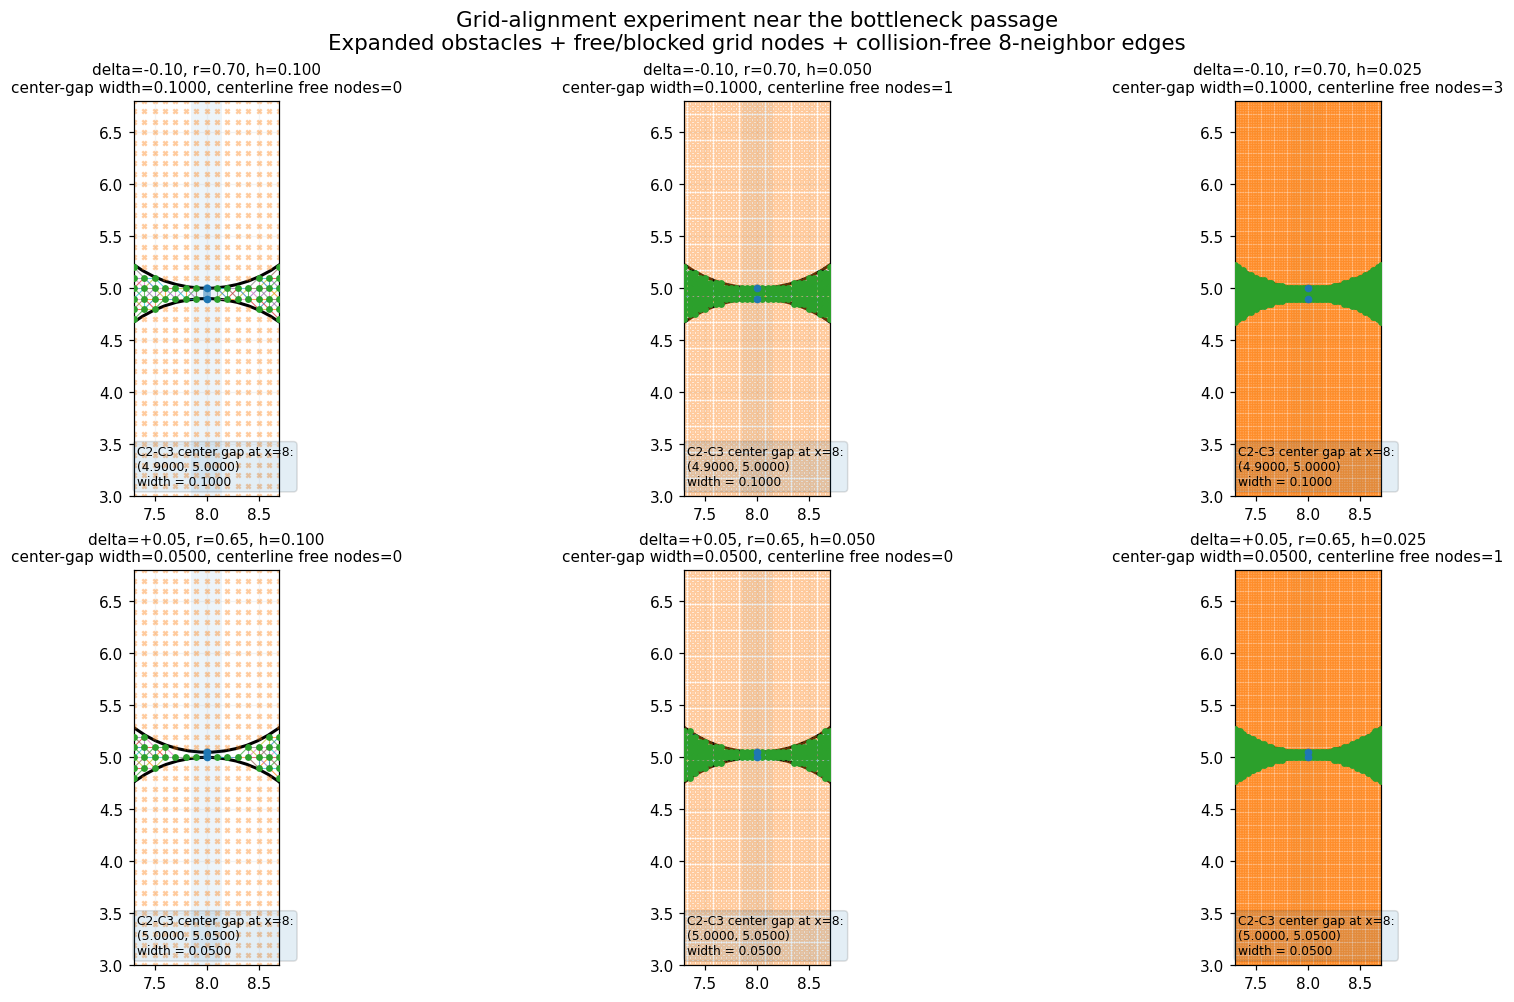

In [18]:
# 시각화 및 격자점 개수 비교
def count_centerline_gap_nodes(free_nodes, delta, r, tol=1e-9):
    """
    Count free grid nodes exactly on x = 8
    whose y-coordinate lies strictly inside
    the analytic centerline passage.
    """
    y_low, y_high, gap = centerline_gap(delta, r)

    pts = []

    if gap <= 0:
        return 0, pts, (y_low, y_high, gap)

    for x, y in free_nodes:
        if (
    abs(x - X0) < tol
    and y > y_low + tol
    and y < y_high - tol
):
            pts.append((x, y))

    return len(pts), pts, (y_low, y_high, gap)


def plot_case(ax, delta, r, h):
    free_nodes, blocked_nodes, edges = build_local_grid_graph(delta, r, h)
    n_in_gap, gap_pts, (y_low, y_high, gap) = count_centerline_gap_nodes(free_nodes, delta, r)


    # draw expanded obstacles
    R_eff = inflated_radius(r)
    upper = Circle((X0, Y2), R_eff, fill=False, lw=2.0)
    lower = Circle((X0, c3_y(delta)), R_eff, fill=False, lw=2.0)
    ax.add_patch(upper)
    ax.add_patch(lower)

    # draw a vertical "center band" near x=8 to emphasize the bottleneck area
    ax.axvspan(X0 - 0.15, X0 + 0.15, alpha=0.08)

    # draw the analytic centerline gap interval on x=8
    if gap > 0:
        ax.plot([X0, X0], [y_low, y_high], lw=5, alpha=0.5, solid_capstyle="round")
        ax.scatter([X0, X0], [y_low, y_high], s=16, zorder=5)

    # draw collision-free edges
    for (a, b) in edges:
        ax.plot([a[0], b[0]], [a[1], b[1]], lw=0.7, alpha=0.7, zorder=1)

    # draw blocked nodes
    if blocked_nodes:
        bx, by = zip(*blocked_nodes)
        ax.scatter(bx, by, s=8, marker="x", alpha=0.4, zorder=2, label="blocked")

    # draw free nodes
    if free_nodes:
        fx, fy = zip(*free_nodes)
        ax.scatter(fx, fy, s=12, zorder=3, label="free")

    # highlight free nodes lying in the center-gap neighborhood
    if gap_pts:
        gx, gy = zip(*gap_pts)
        ax.scatter(gx, gy, s=40, marker="o", facecolors="none",
                   linewidths=1.5, zorder=4, label="free nodes in center-gap band")

    # cosmetics
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.15)
    ax.set_title(
        f"delta={delta:+.2f}, r={r:.2f}, h={h:.3f}\n"
        f"center-gap width={gap:.4f}, centerline free nodes={n_in_gap}",
        fontsize=10
    )

    # optional text box
    txt = (
        f"C2-C3 center gap at x=8:\n"
        f"({y_low:.4f}, {y_high:.4f})\n"
        f"width = {gap:.4f}"
    )
    ax.text(
        0.02, 0.02, txt,
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment="bottom",
        bbox=dict(boxstyle="round", alpha=0.12)
    )


# -----------------------------
# Main figure: 2 rows x 3 cols
# -----------------------------
fig, axes = plt.subplots(len(cases), len(hs), figsize=(15, 9), constrained_layout=True)

for i, case in enumerate(cases):
    delta = case["delta"]
    r = case["r"]
    for j, h in enumerate(hs):
        plot_case(axes[i, j], delta, r, h)

fig.suptitle(
    "Grid-alignment experiment near the bottleneck passage\n"
    "Expanded obstacles + free/blocked grid nodes + collision-free 8-neighbor edges",
    fontsize=14
)

fig.savefig(
    OUT / "06_grid_alignment.png",
    dpi=170,
    bbox_inches="tight"
)

plt.show()

### 8.4 시각화와 격자점 개수 비교
각 subplot에서:

- 원 두 개: expanded obstacles
- 작은 점: free grid node
- `x` 표시: blocked grid node
- 얇은 선: collision-free 8-neighbor edge
- 가운데 옅은 세로 띠: bottleneck 근처의 시각적 강조 영역
- 빈 원: centerline $x=8$ 위에서 analytic passage 내부에 위치한 free grid node

Centerline 내부 free-node 수는 다음과 같이 변한다.

- $\delta=-0.10$, $r=0.70$:
  $h=0.10,0.05,0.025$에서 각각 $0,1,3$
- $\delta=0.05$, $r=0.65$:
  $h=0.10,0.05,0.025$에서 각각 $0,0,1$

> Continuous configuration space에서는 narrow passage가 존재하더라도,
> grid discretization 이후 passage 내부에 유효한 grid node가 배치되지 않으면
> discrete A* graph가 그 연결성을 표현하지 못할 수 있다.
> 첫 번째 사례에서는 $h=0.05$부터 centerline 내부 node가 나타나는 반면,
> 더 좁은 두 번째 사례에서는 $h=0.025$에서야 내부 node가 생성된다.
> 이는 observed feasibility threshold의 오차가 resolution뿐 아니라
> bottleneck geometry와 grid alignment에도 의존함을 보여준다.

## 9. 최종 결과물

다음 결과를 `results/main`에 저장한다.

- **01_paths.png:** 동일한 $\delta=0$에서 $r=0.6$의 실제 경로와 $r=0.75$의 차단 상태. 회색은 실제 장애물, 붉은 반투명 원은 configuration-space 장애물, 점선은 로봇 중심의 workspace 경계다.
- **02_parameter_plane.png:** A* sweep 결과와 이론 boundary의 overlay.
- **03_thresholds.png:** 각 해상도의 observed threshold와 이론값, 확대 가능한 수치 bracket.
- **04_resolution.png:** 해상도에 따른 평균·최대 오차와 실행 시간.
- **05_barrier.png:** 임계반지름에서 활성화된 obstacle graph와 minimax가 선택한 barrier.
- **06_grid_alignment.png:** narrow passage와 grid alignment에 따른 centerline node representation 비교
- **CSV 및 summary.json:** radius bracket, 오차, 탐색량, 환경 버전과 실험 설정.

이론선과 격자 실험점이 겹치는 것만 보지 말고 오차 축과 CSV를 함께 확인한다. path length는 grid 최단거리이며 해상도 비교의 핵심 지표는 connectivity threshold다.


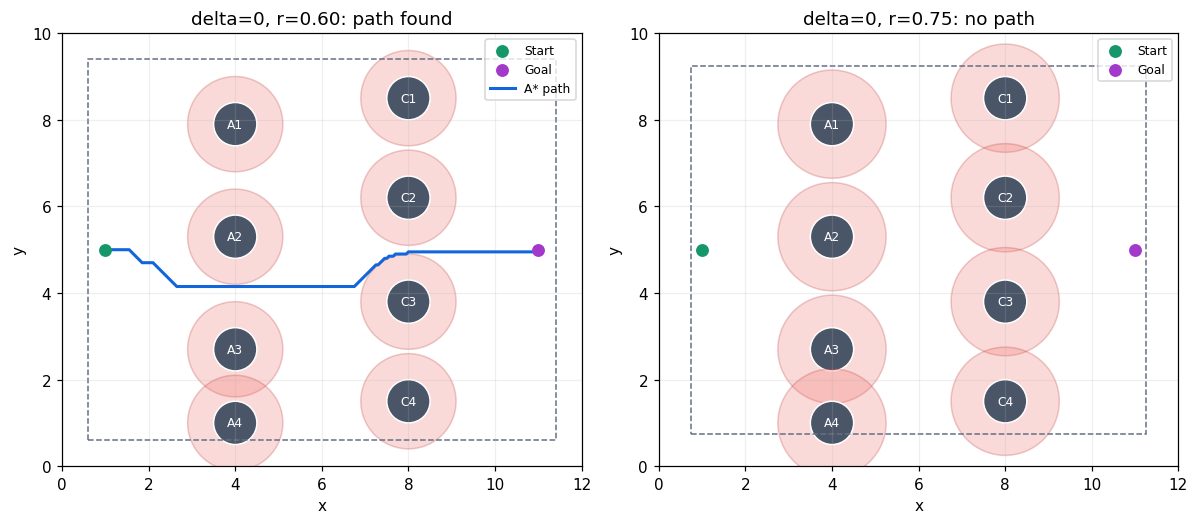

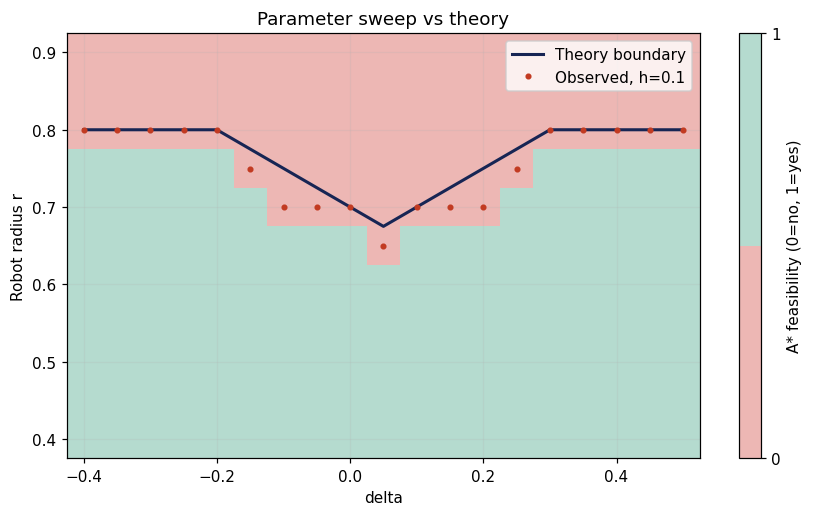

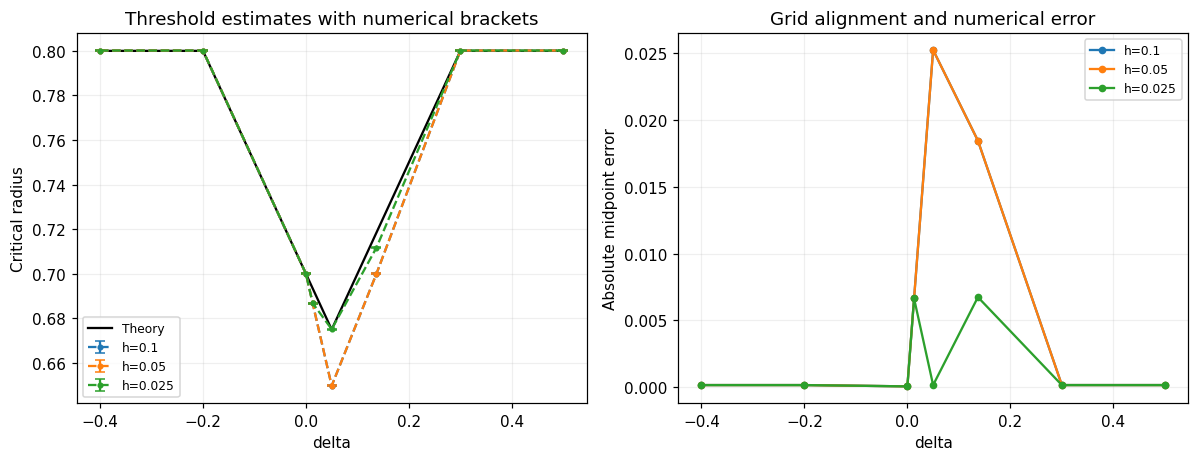

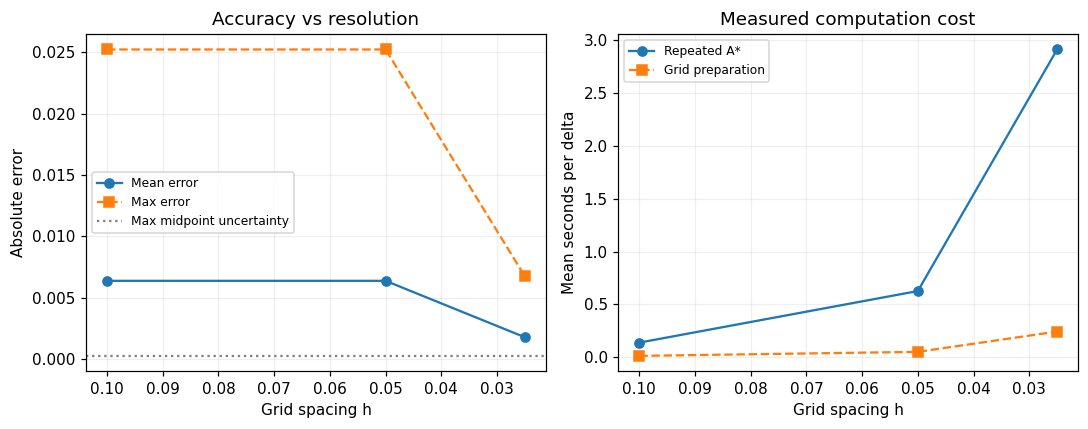

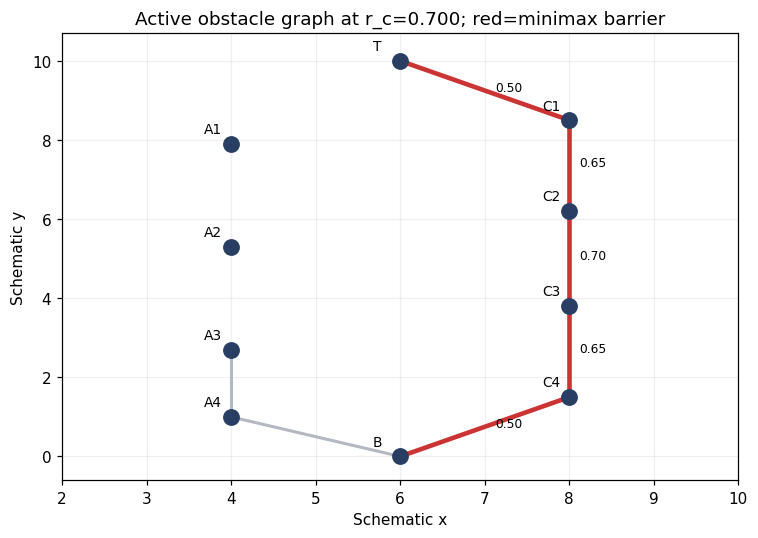

In [19]:
def save_figure(fig,name):
    fig.tight_layout()
    fig.savefig(OUT/name,dpi=170,bbox_inches='tight')
    plt.show()

def draw_scene(ax,obstacles,r):
    for o in obstacles:
        ax.add_patch(Circle((o.x,o.y),o.radius+r,fc='#ef6c66',ec='#bb3434',alpha=0.25))
        ax.add_patch(Circle((o.x,o.y),o.radius,fc='#4a5568',ec='white'))
        ax.text(o.x,o.y,o.name,color='white',ha='center',va='center',fontsize=8)
    ax.add_patch(Rectangle((r,r),L-2*r,H-2*r,fill=False,ls='--',ec='#667085'))
    ax.scatter(*START,c='#15976a',s=55,zorder=5,label='Start')
    ax.scatter(*GOAL,c='#a239ca',s=55,zorder=5,label='Goal')
    ax.set(xlim=(0,L),ylim=(0,H),xlabel='x',ylabel='y',aspect='equal')

fig,axes = plt.subplots(1,2,figsize=(11,4.6))
for ax,r in zip(axes,[0.6,0.75]):
    result = astar(grid_demo,r)
    draw_scene(ax,grid_demo['obstacles'],r)
    if result['found']:
        validate_path(result,grid_demo['obstacles'],r)
        p=np.array(result['path']); ax.plot(p[:,0],p[:,1],c='#1266db',lw=2,label='A* path')
    ax.set_title(f"delta=0, r={r:.2f}: {'path found' if result['found'] else 'no path'}")
    ax.legend(loc='upper right',fontsize=8)
save_figure(fig,'01_paths.png')

fig,ax = plt.subplots(figsize=(8,4.8))
mesh=ax.pcolormesh(DELTA_SWEEP,RADII_SWEEP,sweep,shading='nearest',
                   cmap=ListedColormap(['#edb7b4','#b5dbcf']),vmin=0,vmax=1)
fig.colorbar(mesh,ax=ax,ticks=[0,1],label='A* feasibility (0=no, 1=yes)')
ax.plot(theory_deltas,rc_formula(theory_deltas),c='#172554',lw=2,label='Theory boundary')
ax.plot([x['delta'] for x in boundary_rows],[x['observed'] for x in boundary_rows],
        'o',ms=3,c='#c23b22',label=f'Observed, h={SWEEP_H}')
ax.set(xlabel='delta',ylabel='Robot radius r',title='Parameter sweep vs theory')
ax.legend(); save_figure(fig,'02_parameter_plane.png')

fig,axes=plt.subplots(1,2,figsize=(11,4.3))
axes[0].plot(theory_deltas,rc_formula(theory_deltas),'k-',label='Theory')
for h in RESOLUTIONS:
    rows=[x for x in resolution_rows if x['h']==h]
    xs=np.array([x['delta'] for x in rows]); obs=np.array([x['observed'] for x in rows])
    unc=np.array([x['radius_uncertainty'] for x in rows])
    axes[0].errorbar(xs,obs,yerr=unc,fmt='o--',ms=3,capsize=3,label=f'h={h}')
    axes[1].plot(xs,[x['abs_error'] for x in rows],'o-',ms=4,label=f'h={h}')
axes[0].set(xlabel='delta',ylabel='Critical radius',title='Threshold estimates with numerical brackets')
axes[1].set(xlabel='delta',ylabel='Absolute midpoint error',title='Grid alignment and numerical error')
for ax in axes: ax.legend(fontsize=8)
save_figure(fig,'03_thresholds.png')

fig,axes=plt.subplots(1,2,figsize=(10,4))
hs=[x['h'] for x in resolution_summary]
axes[0].plot(hs,[x['mean_error'] for x in resolution_summary],'o-',label='Mean error')
axes[0].plot(hs,[x['max_error'] for x in resolution_summary],'s--',label='Max error')
axes[0].axhline(BISECTION_TOL/2,color='gray',ls=':',label='Max midpoint uncertainty')
axes[0].set(xlabel='Grid spacing h',ylabel='Absolute error',title='Accuracy vs resolution')
axes[1].plot(hs,[x['mean_search_seconds'] for x in resolution_summary],'o-',label='Repeated A*')
axes[1].plot(hs,[x['mean_prep_seconds'] for x in resolution_summary],'s--',label='Grid preparation')
axes[1].set(xlabel='Grid spacing h',ylabel='Mean seconds per delta',title='Measured computation cost')
for ax in axes: ax.invert_xaxis(); ax.legend(fontsize=8)
save_figure(fig,'04_resolution.png')

fig,ax=plt.subplots(figsize=(7,5))
obstacles=make_obstacles(0); graph=build_graph(obstacles); rc,chain=minimax(graph)
positions={o.name:(o.x,o.y) for o in obstacles}; positions.update(T=(6,10),B=(6,0))
for u in graph:
    for v,w in graph[u].items():
        if u<v and w<=rc+EPS:
            p,q=positions[u],positions[v]
            ax.plot([p[0],q[0]],[p[1],q[1]],color='#b2b8c4',lw=2)
for u,v in zip(chain,chain[1:]):
    p,q=positions[u],positions[v]
    ax.plot([p[0],q[0]],[p[1],q[1]],color='#cc3434',lw=3)
    ax.text((p[0]+q[0])/2+0.12,(p[1]+q[1])/2,f'{graph[u][v]:.2f}',fontsize=8)
for name,p in positions.items():
    ax.scatter(*p,s=100,c='#283e63',zorder=5)
    ax.annotate(name,p,xytext=(-18,7),textcoords='offset points',fontsize=9)
ax.set(xlim=(2,10),ylim=(-0.6,10.7),title=f'Active obstacle graph at r_c={rc:.3f}; red=minimax barrier',
       xlabel='Schematic x',ylabel='Schematic y')
save_figure(fig,'05_barrier.png')


In [20]:
def write_csv(name,rows):
    with (OUT/name).open('w',encoding='utf-8-sig',newline='') as f:
        writer=csv.DictWriter(f,fieldnames=list(rows[0]))
        writer.writeheader(); writer.writerows(rows)

write_csv('parameter_sweep.csv',sweep_rows)
write_csv('observed_boundary.csv',boundary_rows)
write_csv('resolution_thresholds.csv',resolution_rows)
write_csv('resolution_summary.csv',resolution_summary)
write_csv('sanity_checks.csv',sanity)
summary={'project':'Configuration-Space Connectivity Analysis for 2D Motion Planning',
         'python':sys.version,'platform':platform.platform(),'numpy':np.__version__,
         'matplotlib':matplotlib.__version__,'contact_is_collision':True,'epsilon':EPS,
         'full_sweep':FULL_SWEEP,'sweep_h':SWEEP_H,'delta_sweep':DELTA_SWEEP.tolist(),
         'radii_sweep':RADII_SWEEP.tolist(),'delta_compare':DELTA_COMPARE.tolist(),
         'resolutions':RESOLUTIONS,'bisection_tolerance':BISECTION_TOL,
         'resolution_summary':resolution_summary}
(OUT/'summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
print('All checks passed. Saved:')
for p in sorted(OUT.iterdir()): print(p)


All checks passed. Saved:
results/main/01_paths.png
results/main/02_parameter_plane.png
results/main/03_thresholds.png
results/main/04_resolution.png
results/main/05_barrier.png
results/main/06_grid_alignment.png
results/main/observed_boundary.csv
results/main/parameter_sweep.csv
results/main/resolution_summary.csv
results/main/resolution_thresholds.csv
results/main/sanity_checks.csv
results/main/summary.json


## 10. 주요 결과와 한계

### 10.1 주요 결과

1. Configuration-space obstacle contact를 weighted graph로 표현하고,

$$
r_c=\min_{P:T\leadsto B}\max_{e\in P}\tau_e
$$

를 이용해 left-to-right feasibility가 사라지는 critical robot radius를 계산했다.

2. $C_3$의 위치를 $\delta$로 변화시켰을 때,
analytic critical radius $r_c(\delta)$는 piecewise-linear boundary를 형성했으며
$\delta=-0.2,\;0.05,\;0.3$에서 active barrier 또는 bottleneck 구조가 전환되었다.

3. 직접 구현한 grid A*를 이용해 continuous-space 결과를 수치적으로 검증했다.
Grid spacing을 $h=0.10,0.05,0.025$로 줄였을 때,
$h=0.025$에서 mean absolute threshold error는 약 $0.00177$까지 감소했다.
반면 search time과 expanded-node 수는 크게 증가해
resolution과 computation cost 사이의 trade-off를 확인했다.

4. 일부 parameter에서는 continuous space에 narrow passage가 존재하더라도
grid 내부에 passage를 표현할 node가 없어 A*가 더 일찍 실패했다.
추가적인 grid-alignment case study를 통해 이 오차가 단순한 grid spacing뿐 아니라
bottleneck geometry와 grid-node alignment에도 의존함을 확인했다.

### 10.2 한계

이 실험은 static 2D workspace에서 원형 holonomic robot과 원형 obstacle의
geometric feasibility를 분석한 것이다.

현재 구현에는 다음 요소가 포함되지 않는다.

- vehicle orientation과 steering constraint
- velocity, acceleration 등의 vehicle dynamics
- moving obstacles와 motion prediction
- interaction-aware planning
- sensor uncertainty를 직접 포함한 probabilistic planning

따라서 본 프로젝트의 결과는 실제 autonomous-driving planner 전체의 성능을 의미하지 않으며,
configuration-space connectivity와 discretized path planning 사이의 관계를 분석한
제한된 geometric planning experiment로 해석한다.